# SenPa-MAE Test

In [1]:
import sys
import os
import torch
import numpy as np
from pathlib import Path

# Set up paths
os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)

# Import necessary modules
import hydra
from omegaconf import OmegaConf
from hydra.core.global_hydra import GlobalHydra
from hydra import initialize, compose
from geofm_src.factory import create_dataset, create_model, model_registry, dataset_registry

# Initialize Hydra
# Clear any previous initialization
GlobalHydra.instance().clear()
# Initialize with the correct config path
initialize(config_path="../geofm_src/configs/", caller_stack_depth=2)

# Print available models in the registry
print("Available models in the registry:")
for model_name in model_registry.keys():
    print(f"- {model_name}")

# Print available datasets in the registry
print("\nAvailable datasets in the registry:")
for dataset_name in dataset_registry.keys():
    print(f"- {dataset_name}")

Adding /home/ando to sys.path


/home/ando/.conda/envs/fm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Available models in the registry:
- croma
- dinov2
- softcon
- dofa
- senpamae
- panopticon
- galileo
- anysat

Available datasets in the registry:
- geobench
- resisc45
- benv2
- corine
- digital_typhoon
- tropical_cyclone
- hyperview
- fmow
- dummy


/data/tmp/ipykernel_797481/2916192492.py:31: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../geofm_src/configs/", caller_stack_depth=2)


In [2]:
# Function to create a dummy dataset config
def create_dummy_dataset_config(num_channels=4, image_resolution=224, num_classes=19, task="classification", senpamae_channels=[0,1,2,3]):
    """Create a dummy dataset config for testing."""
    config = {
        "dataset_type": "dummy",
        "num_channels": num_channels,
        "image_resolution": image_resolution,
        "num_classes": num_classes,
        "task": task,
        "band_gsds": [10.0] * (num_channels),  # Ground sample distance for each band
        "senpamae_channels": senpamae_channels,  # For SenPaMAE model
        "senpamae_srf_name": "rfs_sentinel2_a.npy"  # For SenPaMAE model
    }
    return OmegaConf.create(config)

# Function to load a model config
def load_model_config(model_name):
    """Load a model config from the configs directory."""
    try:
        # Try to load the model config using Hydra
        model_config = compose(config_name=f"{model_name}")
        return model_config
    except Exception as e:
        print(f"Error loading model config: {e}")
        # Create a basic model config if loading fails
        config = {
            "model_type": 'senpamae',
            "embed_dim": 768,
            "image_resolution": 144,
            "pretrained_path": '/data/panopticon/other_model_ckpts/senpamae_doubleParameterEmbedding.pt',
            "num_channels": 8,
            "segm_blk_indices": [4,6,10,11],
            "accel_cls_blk_indices": [8, 9, 10, 11],
            "default_cls_blk_indices": [11],
            "default_feat_out_dim": 768
        }
        return OmegaConf.create(config)
    
# Function to instantiate and test a model
def test_model(model_name, dataset_config=None):
    """Instantiate a model and run a forward pass with dummy data."""
    print(f"\n--- Testing {model_name} model ---")
    
    # Load model config
    model_config = load_model_config(model_name)
    model_config.model_type = model_name
    
    # Adjust model config to match dataset
    # if dataset_config:
    #     model_config.num_channels = dataset_config.num_channels
    #     model_config.image_resolution = dataset_config.image_resolution
    
    print(f"Model config:")
    print(OmegaConf.to_yaml(model_config))
    
    # try:
        # Create model
    model = create_model(model_config, dataset_config)
    print(f"Successfully created {model_name} model")
    
    # Create dummy input
    batch_size = 5
    channels = dataset_config.num_channels
    resolution = dataset_config.image_resolution
    dummy_input = torch.rand(batch_size, channels, resolution, resolution)

    print(f"Dummy input shape: {dummy_input.shape}")
    
    # Get blocks (features)
    model.load_encoder(model_config.default_cls_blk_indices)
    blocks = model.get_blocks(dummy_input)
    print(f"Extracted {len(blocks)} feature blocks")
    
    # Get feature vector
    features = model.default_blocks_to_featurevec(blocks)
    print(f"Feature vector shape: {features.shape}")
    
    return model, features
    
    # except Exception as e:
    #     print(f"Error instantiating or running {model_name} model: {e}")
    #     return None, None

In [6]:
dummy_dataset_config = create_dummy_dataset_config(num_channels=8, image_resolution=144, senpamae_channels=[0,1,2,3,4,5,6,7])
print("\nDummy dataset config:")
print(OmegaConf.to_yaml(dummy_dataset_config))


Dummy dataset config:
dataset_type: dummy
num_channels: 8
image_resolution: 144
num_classes: 19
task: classification
band_gsds:
- 10.0
- 10.0
- 10.0
- 10.0
- 10.0
- 10.0
- 10.0
- 10.0
senpamae_channels:
- 0
- 1
- 2
- 3
- 4
- 5
- 6
- 7
senpamae_srf_name: rfs_sentinel2_a.npy



In [7]:
# Test a specific model (e.g., SenPaMAE)
model_name = "senpamae"  # Change this to test different models
model, features = test_model(model_name, dummy_dataset_config)



--- Testing senpamae model ---
Error loading model config: Primary config directory not found.
Check that the config directory '/home/ando/.conda/envs/fm/lib/python3.10/site-packages/IPython/geofm_src/configs' exists and readable
Model config:
model_type: senpamae
embed_dim: 768
image_resolution: 144
pretrained_path: /data/panopticon/other_model_ckpts/senpamae_doubleParameterEmbedding.pt
num_channels: 8
segm_blk_indices:
- 4
- 6
- 10
- 11
accel_cls_blk_indices:
- 8
- 9
- 10
- 11
default_cls_blk_indices:
- 11
default_feat_out_dim: 768

Successfully created senpamae model
Dummy input shape: torch.Size([5, 8, 144, 144])


INFO:root:SRF shape: torch.Size([1, 8, 2301])
INFO:root:Selected GSDs: tensor([[10., 10., 10., 10., 10., 10., 10., 10.]])


Band GSDs: [10. 10. 10. 10. 10. 10. 10. 10.]
Extracted 1 feature blocks
Feature vector shape: torch.Size([5, 768])


In [21]:
import numpy as np

path = '/home/ando/fm-playground/geofm_src/foundation_models/SenPaMAE/responsefunctions/rfs_landsat.npy'
rfs = np.load(path)
print(rfs.shape)






(2301, 7)


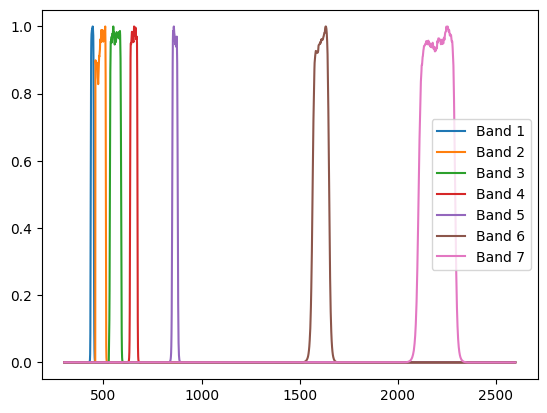

In [25]:
import matplotlib.pyplot as plt

b1 = rfs[:,0]
b2 = rfs[:,1]
b3 = rfs[:,2]
b4 = rfs[:,3]
b5 = rfs[:,4]
b6 = rfs[:,5]
b7 = rfs[:,6]


x_values = np.arange(len(b1)) + 300  # Add 300 to all x-values

plt.plot(x_values, b1, label='Band 1')
plt.plot(x_values, b2, label='Band 2')
plt.plot(x_values, b3, label='Band 3')
plt.plot(x_values, b4, label='Band 4')
plt.plot(x_values, b5, label='Band 5')
plt.plot(x_values, b6, label='Band 6')
plt.plot(x_values, b7, label='Band 7')

# plt.xlim(300, 1050)  # Adjust x-limits accordingly
# plt.xlim(400, 500)
plt.legend()
plt.show()

In [30]:
import numpy as np

path = '/home/ando/fm-playground/geofm_src/foundation_models/SenPaMAE/responsefunctions/rfs_sentinel2_a.npy'
rfs = np.load(path)
print(rfs.shape)

path = '/home/ando/fm-playground/enmap_srf.npy'
rfs = np.load(path)
print(rfs.shape)




(2301, 10)
(2201, 224)


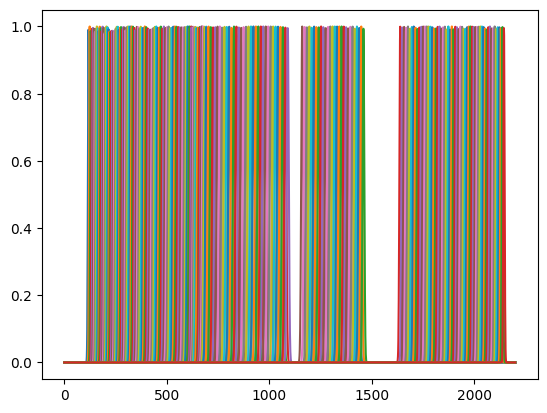

In [37]:
import matplotlib.pyplot as plt
for i in range(len(rfs[0])):
    plt.plot(rfs[:,i])
plt.show()

In [29]:
rfs[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

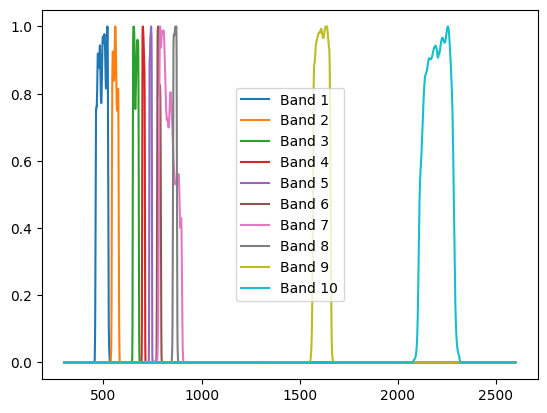

In [27]:
import matplotlib.pyplot as plt

b1 = rfs[:,0]
b2 = rfs[:,1]
b3 = rfs[:,2]
b4 = rfs[:,3]
b5 = rfs[:,4]
b6 = rfs[:,5]
b7 = rfs[:,6]
b8 = rfs[:,7]
b9 = rfs[:,8]
b10 = rfs[:,9]


x_values = np.arange(len(b1)) + 300  # Add 300 to all x-values

plt.plot(x_values, b1, label='Band 1')
plt.plot(x_values, b2, label='Band 2')
plt.plot(x_values, b3, label='Band 3')
plt.plot(x_values, b4, label='Band 4')
plt.plot(x_values, b5, label='Band 5')
plt.plot(x_values, b6, label='Band 6')
plt.plot(x_values, b7, label='Band 7')
plt.plot(x_values, b8, label='Band 8')
plt.plot(x_values, b9, label='Band 9')
plt.plot(x_values, b10, label='Band 10')
# plt.xlim(300, 1050)  # Adjust x-limits accordingly
# plt.xlim(400, 500)
plt.legend()
plt.show()

In [23]:
b6.min(), b6.max()

(-3.1e-05, 1.0)

In [8]:
import numpy as np

path = '/home/ando/fm-playground/geofm_src/foundation_models/SenPaMAE/responsefunctions/rfs_superdove.npy'
rfs = np.load(path)
print(rfs.shape)






(2301, 8)
